# Empirical DMS Replicate Analysis

This notebook fits joint `multidms` models to empirical SARS-CoV-2 spike DMS data,
fitting each replicate independently to assess reproducibility of inferred mutation
effects (betas) and condition-specific shifts between replicates.

In [116]:
import multidms
from multidms import Model, Data, AAS_WITHSTOP_WITHGAP
import multidms.jaxmodels

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy
import os

## Parameters

In [90]:
# Data paths
# Note that if you want to understand how we got these training functional scores,
# you can reference the manuscript analysis site/notebook here:
# https://github.com/matsengrp/SARS-CoV-2_spike_multidms/blob/main/spike-analysis.ipynb
# we write this file at cell 17 over there.
functional_scores_fp = "training_functional_scores.csv.gz"
output_dir = "empirical_output"

# Model configuration
reference = "Omicron_BA1"  # Reference condition
conditions = ["Delta", "Omicron_BA1", "Omicron_BA2"]
replicates = [1, 2]

# Regularization parameters (matching simulation notebook)
l2reg = 1e-7  # Ridge regularization strength on betas
fusionreg = 4e-5  # Fusion lasso regularization strength between conditional effects
beta0_ridge = 0  # Fusion ridge regularization strength on beta0s

# Block coordinate descent parameters
block_iters = 1000  # Max block coordinate descent iterations
block_tol = 1e-6  # Convergence tolerance for block coordinate descent

# Global epistasis optimization parameters
ge_tol = 1e-4  # Convergence tolerance
ge_maxiter = 1000  # Max iterations
ge_maxls = 40  # Max line search steps

# Calibration parameters
cal_tol = 1e-4  # Convergence tolerance
cal_maxiter = 1000  # Max iterations
cal_maxls = 40  # Max line search steps

# Loss function
loss_fn = "functional_score_loss"
loss_kwargs = {"δ": 1.0}

# Initial parameter values
beta0_init = {
    "Delta": 0.0,
    "Omicron_BA1": 0.0,
    "Omicron_BA2": 0.0,
}
alpha_init = {
    "Delta": 6.0,
    "Omicron_BA1": 6.0,
    "Omicron_BA2": 6.0,
}

# Other settings
warmstart = False
beta_clip = (-10, 10)  # Clip betas during optimization for stability
global_epistasis = "Sigmoid"

# Functional score clipping (using data's natural range)
functional_score_min = -3.5
functional_score_max = 2.5

# Filtering
n_sub_thresh = 10  # Maximum number of substitutions per variant

In [91]:
# Convert string parameters to objects
loss_fn = getattr(multidms.jaxmodels, loss_fn)
global_epistasis = getattr(multidms.jaxmodels, global_epistasis)()

In [92]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

## Data Loading and Preprocessing

In [93]:
df_raw = (
    pd.read_csv(functional_scores_fp, keep_default_na=True)
    .assign(aa_substitutions=lambda x: x["aa_substitutions"].fillna(""))
)
print(f"Raw data shape: {df_raw.shape}")
df_raw.head()

Raw data shape: (689433, 5)


,func_score,aa_substitutions,condition,replicate,n_subs
0,0.4616,N87T L517F T1006A,Delta,1,3
1,1.5096,D80L,Delta,1,1
2,-0.7202,A1026V D1168Y,Delta,1,2
3,1.1890,G75W K1154E,Delta,1,2
4,-1.2116,T307S S803L A893V,Delta,1,3


In [94]:
# Check data structure
print("Conditions:", df_raw["condition"].unique())
print("Replicates:", df_raw["replicate"].unique())
print("\nVariants per condition x replicate:")
print(df_raw.groupby(["condition", "replicate"]).size())

Conditions: ['Delta' 'Omicron_BA1' 'Omicron_BA2']
Replicates: [1 2]

Variants per condition x replicate:
condition    replicate
Delta        1             75282
             2             74334
Omicron_BA1  1            122470
             2            109461
Omicron_BA2  1            157771
             2            150115
dtype: int64


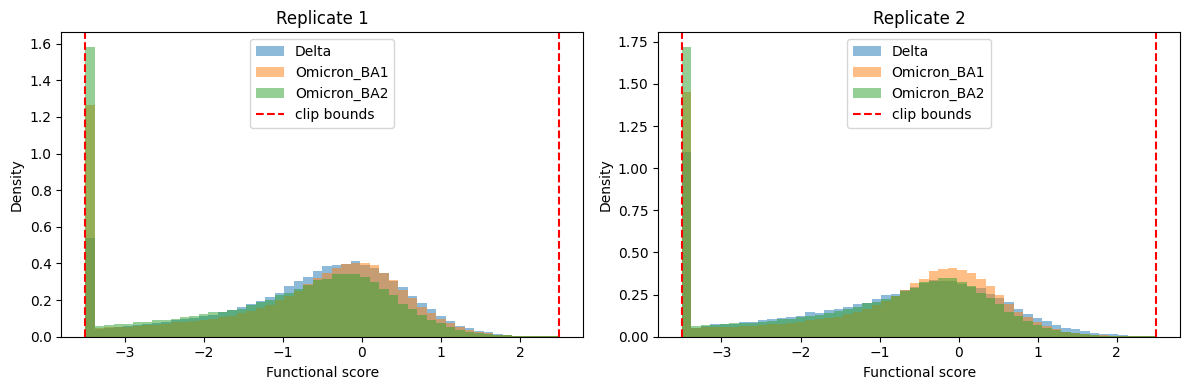

In [95]:
# Functional score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, rep in enumerate(replicates):
    ax = axes[i]
    df_rep = df_raw.query(f"replicate == {rep}")
    for cond in conditions:
        df_cond = df_rep.query(f"condition == '{cond}'")
        ax.hist(df_cond["func_score"], bins=50, alpha=0.5, label=cond, density=True)
    ax.axvline(functional_score_min, color="red", linestyle="--", label="clip bounds")
    ax.axvline(functional_score_max, color="red", linestyle="--")
    ax.set_xlabel("Functional score")
    ax.set_ylabel("Density")
    ax.set_title(f"Replicate {rep}")
    ax.legend()

plt.tight_layout()
plt.show()

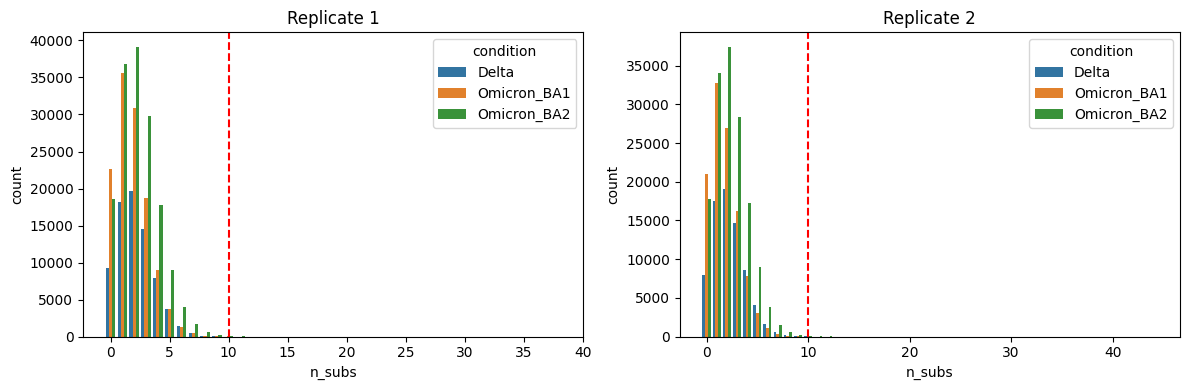

In [96]:
# Number of substitutions distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, rep in enumerate(replicates):
    ax = axes[i]
    df_rep = df_raw.query(f"replicate == {rep}")
    sns.countplot(data=df_rep, x="n_subs", hue="condition", ax=ax, native_scale=True)
    ax.axvline(n_sub_thresh, color="red", linestyle="--")
    ax.set_title(f"Replicate {rep}")

plt.tight_layout()
plt.show()

## Prepare Data for Each Replicate

In [97]:
def prepare_replicate_data(df_raw, replicate, n_sub_thresh, func_score_min, func_score_max):
    """Prepare data for a single replicate."""
    # Filter to replicate
    df = df_raw.query(f"replicate == {replicate}").copy()
    
    # Remove variants with deletions
    df = df.loc[df.aa_substitutions.str.count("-") == 0, :]
    
    # Aggregate by condition and aa_substitutions
    df = (
        df.groupby(["condition", "aa_substitutions"])
        .agg({"n_subs": "first", "func_score": "mean"})
        .reset_index()
    )
    
    # Filter by number of substitutions
    df = df.query("n_subs <= @n_sub_thresh")
    
    # Clip functional scores
    df["func_score"] = df["func_score"].clip(lower=func_score_min, upper=func_score_max)
    
    # Add replicate column back for multidms.Data
    df["replicate"] = f"rep_{replicate}"
    
    return df

In [98]:
# Prepare data for each replicate
replicate_dfs = {}
for rep in replicates:
    replicate_dfs[rep] = prepare_replicate_data(
        df_raw, rep, n_sub_thresh, functional_score_min, functional_score_max
    )
    print(f"Replicate {rep}: {replicate_dfs[rep].shape[0]} variants")
    print(replicate_dfs[rep].groupby("condition").size())
    print()

Replicate 1: 155219 variants
condition
Delta          27029
Omicron_BA1    69136
Omicron_BA2    59054
dtype: int64

Replicate 2: 144888 variants
condition
Delta          27438
Omicron_BA1    60977
Omicron_BA2    56473
dtype: int64



In [99]:
replicate_dfs[2]

,condition,aa_substitutions,n_subs,func_score,replicate
0,Delta,,0,-0.196403,rep_2
1,Delta,A1015D,1,-2.054900,rep_2
2,Delta,A1015S,1,0.168720,rep_2
3,Delta,A1015T,1,-0.189925,rep_2
4,Delta,A1015T A1020M L1063F V1189A,4,-2.737400,rep_2
...,...,...,...,...,...
144928,Omicron_BA2,Y91T T553I,2,-3.375950,rep_2
144929,Omicron_BA2,Y91V A1078S,2,-2.483250,rep_2
144930,Omicron_BA2,Y91V S112N M177K L335P N405A C671R K679R T859A...,9,-3.500000,rep_2
144931,Omicron_BA2,Y91V S98Y D138* Y144V N280D N405P P463S S982R ...,9,-2.407900,rep_2


In [100]:
# Check wildtype entries
for rep in replicates:
    print(f"\nReplicate {rep} wildtype entries:")
    print(replicate_dfs[rep].query("aa_substitutions == ''"))


Replicate 1 wildtype entries:
         condition aa_substitutions  n_subs  func_score replicate
0            Delta                        0   -0.136373     rep_1
27032  Omicron_BA1                        0   -0.101382     rep_1
96185  Omicron_BA2                        0   -0.091640     rep_1

Replicate 2 wildtype entries:
         condition aa_substitutions  n_subs  func_score replicate
0            Delta                        0   -0.196403     rep_2
27440  Omicron_BA1                        0   -0.086101     rep_2
88435  Omicron_BA2                        0   -0.070555     rep_2


## Fit Models for Each Replicate

In [ ]:
def fit_replicate_model(df, reference, global_epistasis_name, loss_fn_name, 
                        l2reg, fusionreg, beta0_ridge, warmstart, block_iters, 
                        block_tol, beta0_init, alpha_init, beta_clip,
                        ge_tol, ge_maxiter, ge_maxls, cal_tol, cal_maxiter, 
                        cal_maxls, loss_kwargs):
    """Fit a multidms model for a single replicate."""
    
    # Create multidms.Data object
    multidms_data = Data(
        df,
        alphabet=AAS_WITHSTOP_WITHGAP,
        reference=reference,
    )
    
    # Create and fit model
    model_wrapper = Model(
        multidms_data,
        ge_type=global_epistasis_name,
        loss_type=loss_fn_name,
        l2reg=l2reg,
        fusionreg=fusionreg,
        beta0_ridge=beta0_ridge,
    )
    
    model_wrapper.fit(
        warmstart=warmstart,
        maxiter=block_iters,
        tol=block_tol,
        beta0_init=beta0_init,
        alpha_init=alpha_init,
        beta_clip_range=beta_clip,
        ge_kwargs=dict(
            tol=ge_tol,
            maxiter=ge_maxiter,
            maxls=ge_maxls,
            jit=True,
            verbose=False,
        ),
        cal_kwargs=dict(
            tol=cal_tol,
            maxiter=cal_maxiter,
            maxls=cal_maxls,
            jit=True,
            verbose=False,
        ),
        loss_kwargs=loss_kwargs,
    )
    
    return model_wrapper, multidms_data

In [102]:
# Fit models for each replicate
models = {}
data_objects = {}

for rep in replicates:
    print(f"\n{'='*60}")
    print(f"Fitting model for Replicate {rep}")
    print(f"{'='*60}")
    
    model_wrapper, multidms_data = fit_replicate_model(
        replicate_dfs[rep],
        reference=reference,
        global_epistasis_name="Sigmoid",
        loss_fn_name="functional_score_loss",
        l2reg=l2reg,
        fusionreg=fusionreg,
        beta0_ridge=beta0_ridge,
        warmstart=warmstart,
        block_iters=block_iters,
        block_tol=block_tol,
        beta0_init=beta0_init,
        alpha_init=alpha_init,
        beta_clip=beta_clip,
        ge_tol=ge_tol,
        ge_maxiter=ge_maxiter,
        ge_maxls=ge_maxls,
        cal_tol=cal_tol,
        cal_maxiter=cal_maxiter,
        cal_maxls=cal_maxls,
        loss_kwargs=loss_kwargs,
    )
    
    models[rep] = model_wrapper
    data_objects[rep] = multidms_data
    
    print(f"Replicate {rep} fitting complete.")


Fitting model for Replicate 1


/Users/macdre/Matsengrp/projects/dms/.pixi/envs/default/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


iter 1:
  calibration block: error=0.00e+00, stepsize=2.0e+00, iter=1
    Delta: α=6.00, θ=1.00
    Omicron_BA1: α=6.00, θ=1.00
    Omicron_BA2: α=6.00, θ=1.00
  β0 block: error=0.00e+00, stepsize=2.0e+00, iter=1
    Delta: β0=0.00
    Omicron_BA1: β0=0.00
    Omicron_BA2: β0=0.00
  β_nonbundle: error=9.77e-05, stepsize=4.1e+03, iter=267
  β_bundle: error=7.95e-04, stepsize=2.0e+00, iter=1000
  Delta sparsity=5.1%
  Omicron_BA2 sparsity=6.4%
  obj=1.85e-01
  objective_error=8.15e-01
iter 2:
  calibration block: error=4.21e-05, stepsize=3.2e+01, iter=12
    Delta: α=5.96, θ=1.00
    Omicron_BA1: α=6.48, θ=1.00
    Omicron_BA2: α=5.96, θ=1.00
  β0 block: error=1.88e-05, stepsize=1.6e+01, iter=10
    Delta: β0=0.02
    Omicron_BA1: β0=0.03
    Omicron_BA2: β0=0.01
  β_nonbundle: error=9.94e-05, stepsize=2.0e+03, iter=443
  β_bundle: error=5.66e-04, stepsize=1.0e+00, iter=1000
  Delta sparsity=5.1%
  Omicron_BA2 sparsity=6.4%
  obj=1.78e-01
  objective_error=6.69e-03
iter 3:
  calibration 

/Users/macdre/Matsengrp/projects/dms/.pixi/envs/default/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


iter 1:
  calibration block: error=0.00e+00, stepsize=2.0e+00, iter=1
    Delta: α=6.00, θ=1.00
    Omicron_BA1: α=6.00, θ=1.00
    Omicron_BA2: α=6.00, θ=1.00
  β0 block: error=0.00e+00, stepsize=2.0e+00, iter=1
    Delta: β0=0.00
    Omicron_BA1: β0=0.00
    Omicron_BA2: β0=0.00
  β_nonbundle: error=9.72e-05, stepsize=4.1e+03, iter=318
  β_bundle: error=1.93e-03, stepsize=1.0e+00, iter=1000
  Delta sparsity=5.0%
  Omicron_BA2 sparsity=6.8%
  obj=1.59e-01
  objective_error=8.41e-01
iter 2:
  calibration block: error=2.32e-05, stepsize=3.2e+01, iter=12
    Delta: α=5.97, θ=1.00
    Omicron_BA1: α=6.57, θ=1.00
    Omicron_BA2: α=5.96, θ=1.00
  β0 block: error=7.80e-05, stepsize=8.0e+00, iter=9
    Delta: β0=0.01
    Omicron_BA1: β0=0.03
    Omicron_BA2: β0=0.02
  β_nonbundle: error=9.41e-05, stepsize=4.1e+03, iter=44
  β_bundle: error=1.09e-03, stepsize=1.0e+00, iter=1000
  Delta sparsity=5.0%
  Omicron_BA2 sparsity=6.8%
  obj=1.50e-01
  objective_error=8.20e-03
iter 3:
  calibration bl

## Loss Trajectories

Replicate 1: Final loss = 0.000001, Iterations = 42
Replicate 2: Final loss = 0.000001, Iterations = 44


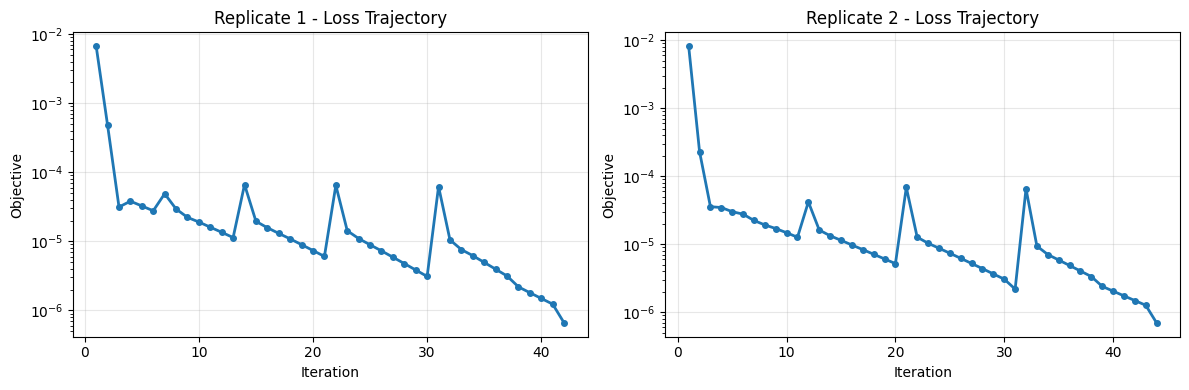

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, rep in enumerate(replicates):
    ax = axes[i]
    loss_trajectory = list(models[rep].convergence_trajectory_df["error"])[1:]
    ax.plot(range(1, len(loss_trajectory) + 1), loss_trajectory, "o-", linewidth=2, markersize=4)
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Objective")
    ax.set_title(f"Replicate {rep} - Loss Trajectory")
    ax.grid(True, alpha=0.3)
    print(f"Replicate {rep}: Final loss = {loss_trajectory[-1]:.6f}, Iterations = {len(loss_trajectory)}")

plt.tight_layout()
plt.show()

## Extract Mutation Parameters

In [104]:
# Get mutations dataframes for each replicate
mutations_dfs = {}
for rep in replicates:
    mutations_dfs[rep] = models[rep].get_mutations_df()
    print(f"Replicate {rep} mutations shape: {mutations_dfs[rep].shape}")

mutations_dfs[1].head()

Replicate 1 mutations shape: (10109, 11)
Replicate 2 mutations shape: (10190, 11)


,wts,sites,muts,times_seen_Delta,times_seen_Omicron_BA1,times_seen_Omicron_BA2,beta_Delta,beta_Omicron_BA1,beta_Omicron_BA2,shift_Delta,shift_Omicron_BA2
mutation,,,,,,,,,,,
M1F,M,1,F,2,0,0,-3.405257,0.000000,0.00000,-3.405257,0.000000
M1I,M,1,I,3,5,6,-2.802855,-6.613803,-6.11550,3.810948,0.498303
M1K,M,1,K,3,0,0,-1.801738,0.000000,0.00000,-1.801738,0.000000
M1L,M,1,L,4,0,0,-6.123293,0.000000,0.00000,-6.123293,0.000000
M1T,M,1,T,0,7,2,-0.005455,-6.148778,-2.85888,6.143323,3.289898


In [105]:
mutations_dfs[2].head()

,wts,sites,muts,times_seen_Delta,times_seen_Omicron_BA1,times_seen_Omicron_BA2,beta_Delta,beta_Omicron_BA1,beta_Omicron_BA2,shift_Delta,shift_Omicron_BA2
mutation,,,,,,,,,,,
M1F,M,1,F,3,0,0,-0.506140,0.00000,0.000000,-0.506140,0.000000
M1I,M,1,I,11,6,10,-5.309109,-7.00548,-7.385231,1.696371,-0.379751
M1K,M,1,K,7,0,0,-2.232584,0.00000,0.000000,-2.232584,0.000000
M1L,M,1,L,9,0,1,-2.784058,0.00000,-5.311799,-2.784058,-5.311799
M1N,M,1,N,1,0,0,-6.169413,0.00000,0.000000,-6.169413,0.000000


## Merge Replicate Results for Comparison

In [106]:
# Rename columns to include replicate identifier
def rename_columns_for_replicate(df, rep):
    """Rename beta and shift columns to include replicate identifier."""
    rename_dict = {}
    for col in df.columns:
        if col.startswith("beta_") or col.startswith("shift_"):
            rename_dict[col] = f"{col}_rep{rep}"
        elif col.startswith("times_seen_"):
            rename_dict[col] = f"{col}_rep{rep}"
    return df.rename(columns=rename_dict)

# Prepare for merge
mutations_rep1 = rename_columns_for_replicate(mutations_dfs[1].copy(), 1)
mutations_rep2 = rename_columns_for_replicate(mutations_dfs[2].copy(), 2)

# Keep only necessary columns from rep2 for merge
rep2_cols = [col for col in mutations_rep2.columns if "_rep2" in col]
mutations_rep2_slim = mutations_rep2[rep2_cols]

# Merge on mutation index
merged_mutations = mutations_rep1.join(mutations_rep2_slim, how="inner")
print(f"Merged mutations shape: {merged_mutations.shape}")
print(f"Rep1 mutations: {mutations_dfs[1].shape[0]}")
print(f"Rep2 mutations: {mutations_dfs[2].shape[0]}")
print(f"Common mutations: {merged_mutations.shape[0]}")

merged_mutations.head()

Merged mutations shape: (9625, 19)
Rep1 mutations: 10109
Rep2 mutations: 10190
Common mutations: 9625


,wts,sites,muts,times_seen_Delta_rep1,times_seen_Omicron_BA1_rep1,times_seen_Omicron_BA2_rep1,beta_Delta_rep1,beta_Omicron_BA1_rep1,beta_Omicron_BA2_rep1,shift_Delta_rep1,shift_Omicron_BA2_rep1,times_seen_Delta_rep2,times_seen_Omicron_BA1_rep2,times_seen_Omicron_BA2_rep2,beta_Delta_rep2,beta_Omicron_BA1_rep2,beta_Omicron_BA2_rep2,shift_Delta_rep2,shift_Omicron_BA2_rep2
mutation,,,,,,,,,,,,,,,,,,,
M1F,M,1,F,2,0,0,-3.405257,0.000000,0.00000,-3.405257,0.000000,3,0,0,-0.506140,0.00000,0.000000,-0.506140,0.000000
M1I,M,1,I,3,5,6,-2.802855,-6.613803,-6.11550,3.810948,0.498303,11,6,10,-5.309109,-7.00548,-7.385231,1.696371,-0.379751
M1K,M,1,K,3,0,0,-1.801738,0.000000,0.00000,-1.801738,0.000000,7,0,0,-2.232584,0.00000,0.000000,-2.232584,0.000000
M1L,M,1,L,4,0,0,-6.123293,0.000000,0.00000,-6.123293,0.000000,9,0,1,-2.784058,0.00000,-5.311799,-2.784058,-5.311799
M1T,M,1,T,0,7,2,-0.005455,-6.148778,-2.85888,6.143323,3.289898,0,3,2,-0.003142,-5.46625,-2.890316,5.463108,2.575933


## Beta Correlations Between Replicates

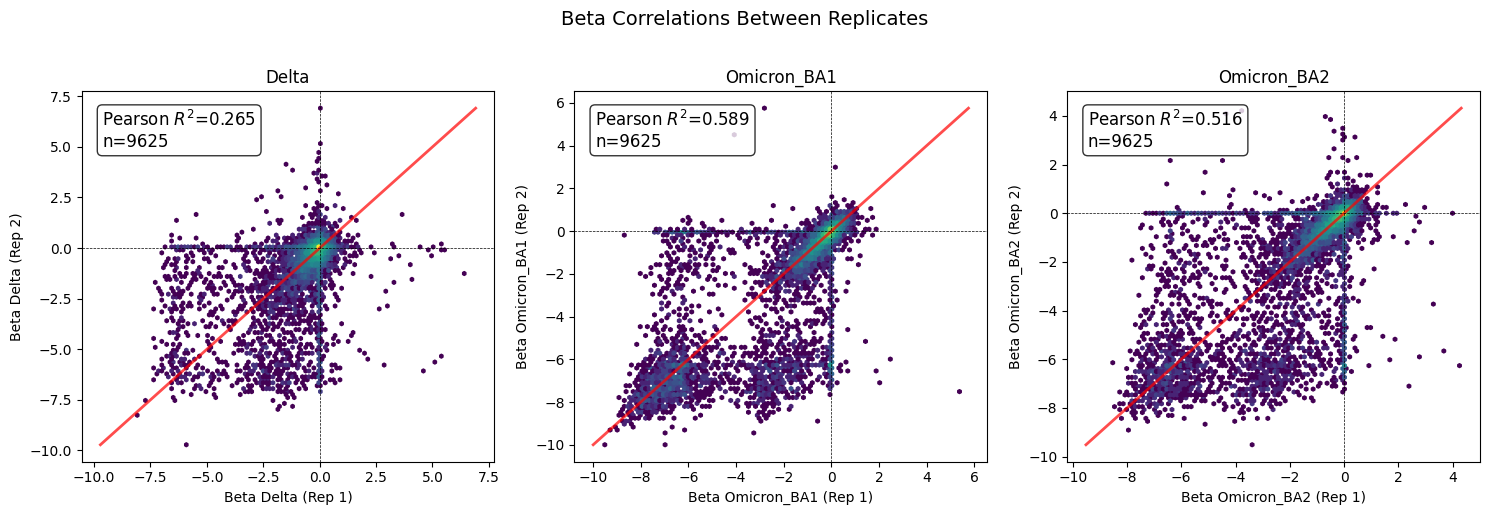

In [107]:
# Plot beta correlations for each condition
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, cond in enumerate(conditions):
    ax = axes[i]
    
    x = merged_mutations[f"beta_{cond}_rep1"]
    y = merged_mutations[f"beta_{cond}_rep2"]
    
    # Remove NaN values
    mask = ~(x.isna() | y.isna())
    x_clean = x[mask]
    y_clean = y[mask]
    
    ax.hexbin(x_clean, y_clean, gridsize=100, cmap="viridis", bins="log")
    
    # Compute correlation
    r = scipy.stats.pearsonr(x_clean, y_clean).statistic
    ax.annotate(
        f"Pearson $R^2$={r**2:.3f}\nn={len(x_clean)}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    
    # Add diagonal line
    lims = [min(x_clean.min(), y_clean.min()), max(x_clean.max(), y_clean.max())]
    ax.plot(lims, lims, "r-", lw=2, alpha=0.7)
    ax.axhline(0, color="k", linestyle="--", lw=0.5)
    ax.axvline(0, color="k", linestyle="--", lw=0.5)
    
    ax.set_xlabel(f"Beta {cond} (Rep 1)")
    ax.set_ylabel(f"Beta {cond} (Rep 2)")
    ax.set_title(f"{cond}")

plt.suptitle("Beta Correlations Between Replicates", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/beta_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Shift Correlations Between Replicates

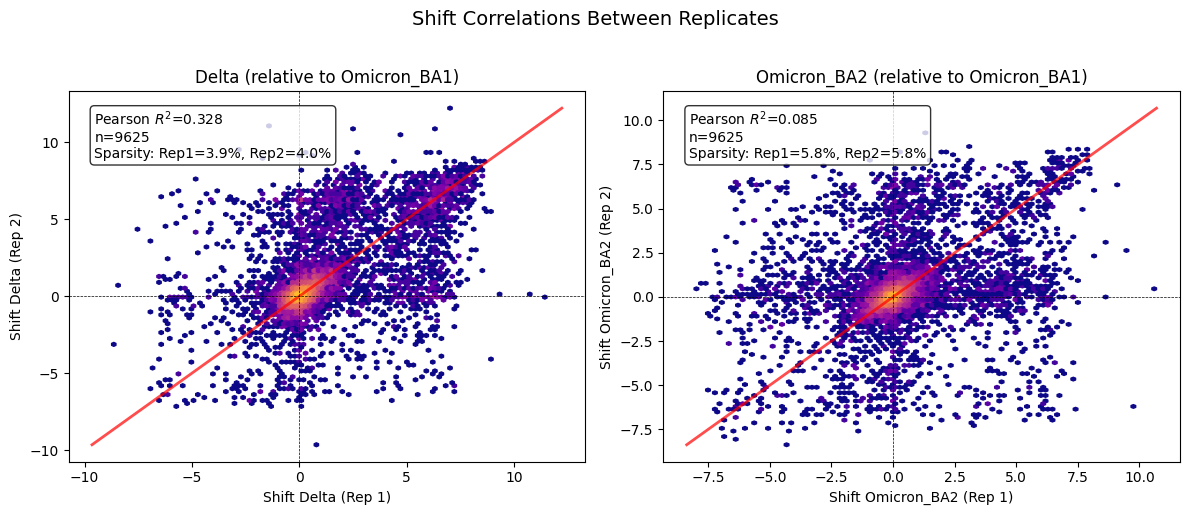

In [108]:
# Plot shift correlations for non-reference conditions
non_ref_conditions = [c for c in conditions if c != reference]

fig, axes = plt.subplots(1, len(non_ref_conditions), figsize=(6 * len(non_ref_conditions), 5))
if len(non_ref_conditions) == 1:
    axes = [axes]

for i, cond in enumerate(non_ref_conditions):
    ax = axes[i]
    
    x = merged_mutations[f"shift_{cond}_rep1"]
    y = merged_mutations[f"shift_{cond}_rep2"]
    
    # Remove NaN values
    mask = ~(x.isna() | y.isna())
    x_clean = x[mask]
    y_clean = y[mask]
    
    ax.hexbin(x_clean, y_clean, gridsize=100, cmap="plasma", bins="log")
    
    # Compute correlation
    r = scipy.stats.pearsonr(x_clean, y_clean).statistic
    
    # Compute sparsity
    sparsity_rep1 = (x_clean == 0).sum() / len(x_clean)
    sparsity_rep2 = (y_clean == 0).sum() / len(y_clean)
    
    ax.annotate(
        f"Pearson $R^2$={r**2:.3f}\nn={len(x_clean)}\nSparsity: Rep1={sparsity_rep1:.1%}, Rep2={sparsity_rep2:.1%}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    
    # Add diagonal line
    lims = [min(x_clean.min(), y_clean.min()), max(x_clean.max(), y_clean.max())]
    ax.plot(lims, lims, "r-", lw=2, alpha=0.7)
    ax.axhline(0, color="k", linestyle="--", lw=0.5)
    ax.axvline(0, color="k", linestyle="--", lw=0.5)
    
    ax.set_xlabel(f"Shift {cond} (Rep 1)")
    ax.set_ylabel(f"Shift {cond} (Rep 2)")
    ax.set_title(f"{cond} (relative to {reference})")

plt.suptitle("Shift Correlations Between Replicates", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/shift_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Shift Distribution Comparison

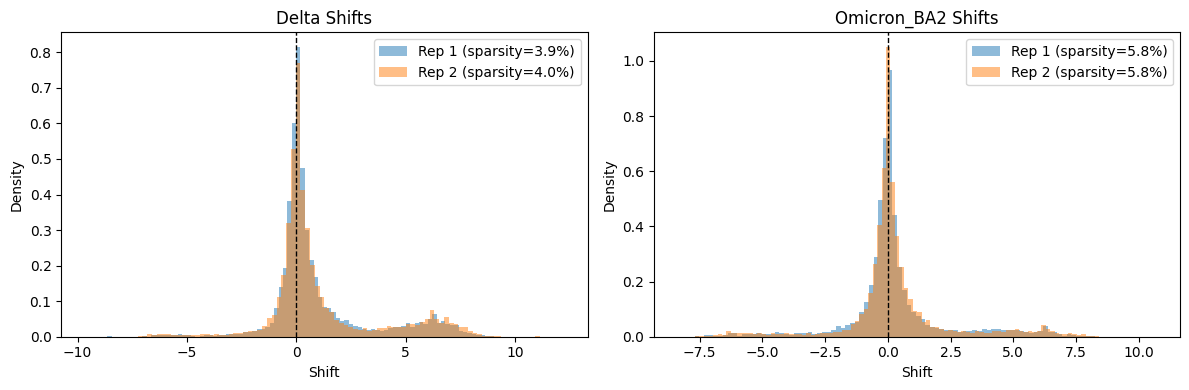

In [109]:
# Plot shift distributions for each replicate
fig, axes = plt.subplots(1, len(non_ref_conditions), figsize=(6 * len(non_ref_conditions), 4))
if len(non_ref_conditions) == 1:
    axes = [axes]

for i, cond in enumerate(non_ref_conditions):
    ax = axes[i]
    
    for rep in replicates:
        shifts = merged_mutations[f"shift_{cond}_rep{rep}"]
        sparsity = (shifts == 0).sum() / len(shifts)
        ax.hist(
            shifts, 
            bins=100, 
            alpha=0.5, 
            label=f"Rep {rep} (sparsity={sparsity:.1%})",
            density=True,
        )
    
    ax.axvline(0, color="k", linestyle="--", lw=1)
    ax.set_xlabel("Shift")
    ax.set_ylabel("Density")
    ax.set_title(f"{cond} Shifts")
    ax.legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/shift_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Beta Distribution Comparison

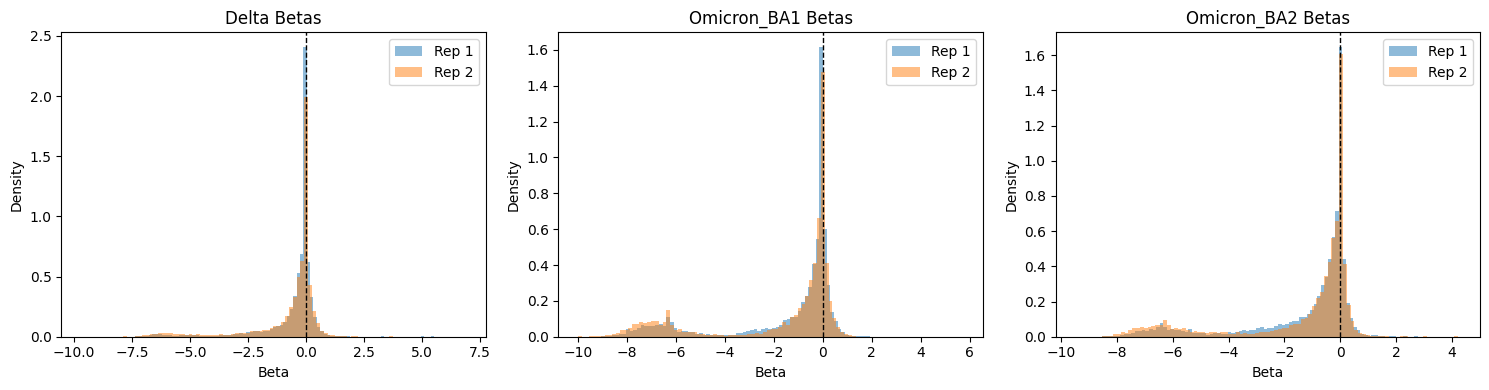

In [110]:
# Plot beta distributions for each condition and replicate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, cond in enumerate(conditions):
    ax = axes[i]
    
    for rep in replicates:
        betas = merged_mutations[f"beta_{cond}_rep{rep}"]
        ax.hist(
            betas, 
            bins=100, 
            alpha=0.5, 
            label=f"Rep {rep}",
            density=True,
        )
    
    ax.axvline(0, color="k", linestyle="--", lw=1)
    ax.set_xlabel("Beta")
    ax.set_ylabel("Density")
    ax.set_title(f"{cond} Betas")
    ax.legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/beta_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Functional Score Predictions

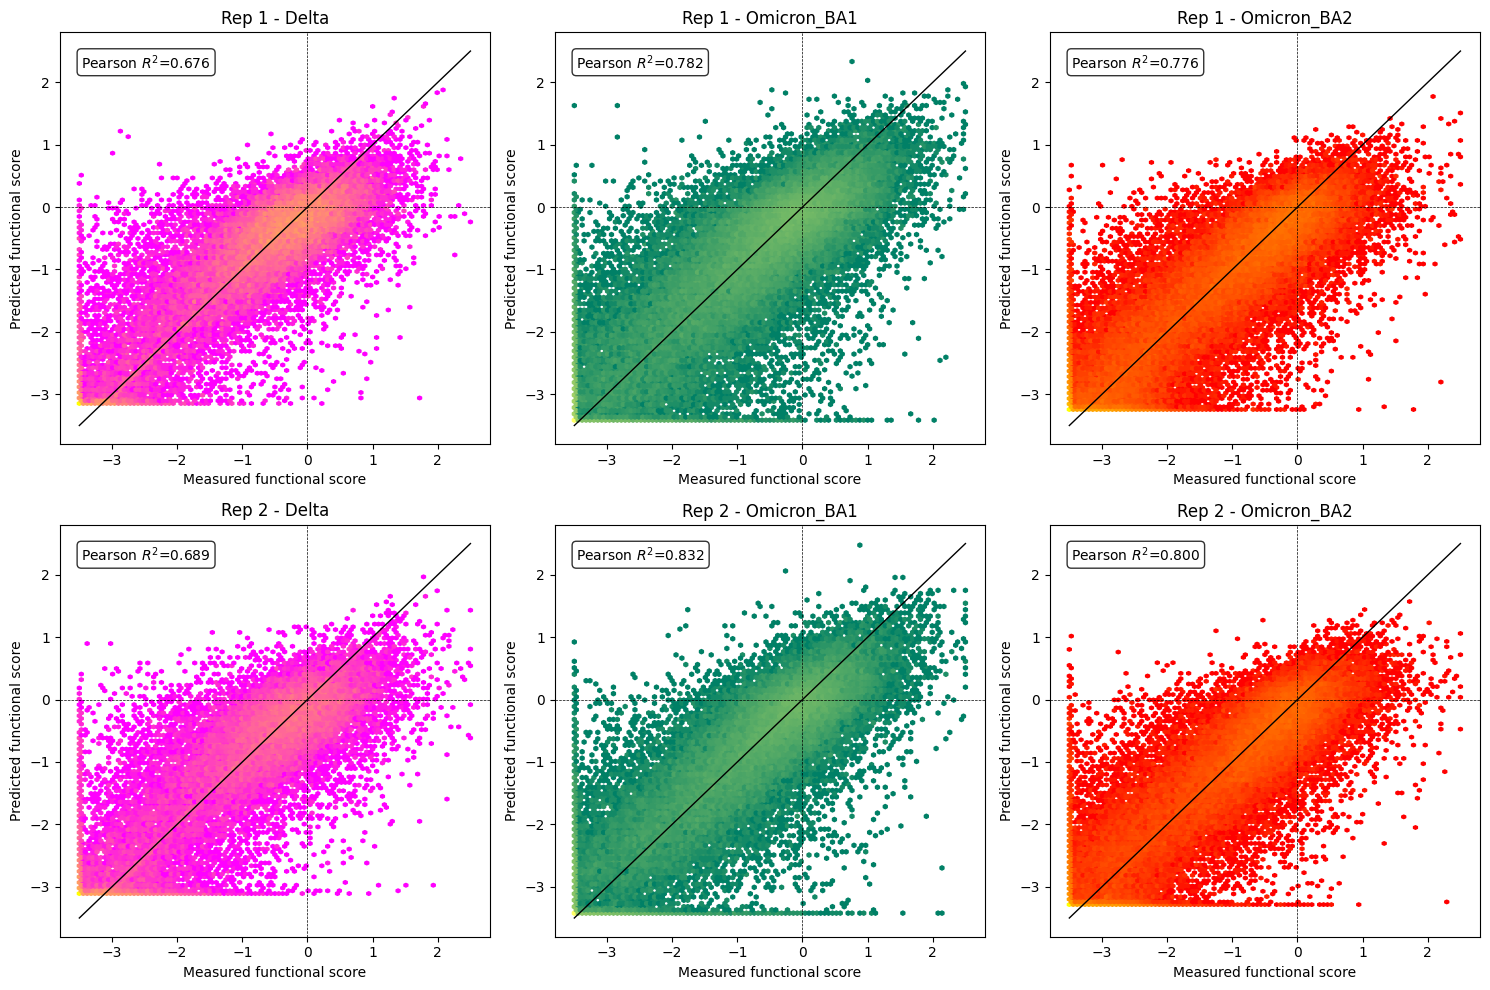

In [111]:
# Plot predicted vs observed functional scores for each replicate
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cmaps = ["spring", "summer", "autumn"]

for row, rep in enumerate(replicates):
    model = models[rep]._jax_model
    data_sets = {
        d: multidms.jaxmodels.Data.from_multidms(data_objects[rep], d)
        for d in data_objects[rep].conditions
    }
    y_preds = model.predict_score(data_sets)
    
    for col, cond in enumerate(conditions):
        ax = axes[row, col]
        
        y = data_sets[cond].functional_scores
        y_pred = y_preds[cond]
        
        ax.hexbin(y, y_pred, cmap=cmaps[col], gridsize=100, bins="log")
        
        r = scipy.stats.pearsonr(y, y_pred).statistic
        ax.annotate(
            f"Pearson $R^2$={r**2:.3f}",
            xy=(0.05, 0.95),
            xycoords="axes fraction",
            fontsize=10,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        )
        
        lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
        ax.plot(lims, lims, "k-", lw=1)
        ax.axhline(0, color="k", linestyle="--", lw=0.5)
        ax.axvline(0, color="k", linestyle="--", lw=0.5)
        
        ax.set_xlabel("Measured functional score")
        ax.set_ylabel("Predicted functional score")
        ax.set_title(f"Rep {rep} - {cond}")

plt.tight_layout()
plt.savefig(f"{output_dir}/functional_score_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## Global Epistasis Functions

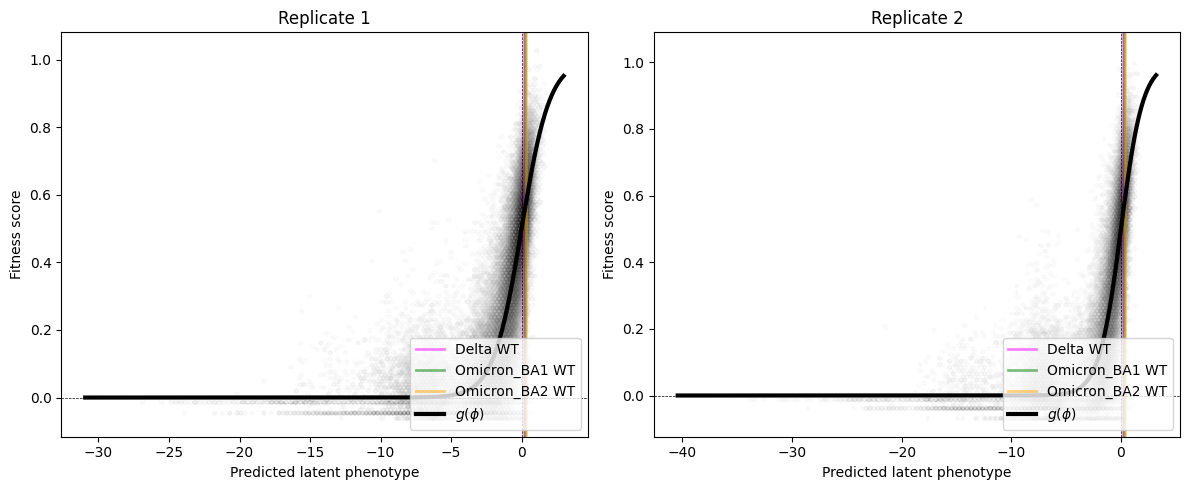

In [112]:
# Plot global epistasis functions for each replicate
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["magenta", "green", "orange"]

for row, rep in enumerate(replicates):
    ax = axes[row]
    model = models[rep]._jax_model
    data_sets = {
        d: multidms.jaxmodels.Data.from_multidms(data_objects[rep], d)
        for d in data_objects[rep].conditions
    }
    
    phi_min = np.inf
    phi_max = -np.inf
    
    for i, cond in enumerate(conditions):
        data_set = data_sets[cond]
        X = data_set.X
        x_wt = data_set.x_wt
        phi = model.φ[cond]
        alpha = model.α[cond]
        phi_pred = phi(X)
        phi_min = min(phi_min, phi_pred.min())
        phi_max = max(phi_max, phi_pred.max())
        phi_pred_wt = phi(x_wt)
        y = data_set.functional_scores
        f = y / alpha + model.global_epistasis(phi(x_wt))
        
        ax.axvline(phi_pred_wt, color=colors[i], lw=2, alpha=0.5, label=f"{cond} WT")
        ax.hexbin(phi_pred, f, cmap="Greys", bins="log", gridsize=100, alpha=0.3)
    
    phi_grid = np.linspace(phi_min, phi_max, 1000)
    ax.plot(phi_grid, model.global_epistasis(phi_grid), "k", lw=3, label=r"$g(\phi)$")
    ax.axhline(0, color="k", linestyle="--", lw=0.5)
    ax.axvline(0, color="k", linestyle="--", lw=0.5)
    ax.set_xlabel("Predicted latent phenotype")
    ax.set_ylabel("Fitness score")
    ax.set_title(f"Replicate {rep}")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f"{output_dir}/global_epistasis.png", dpi=150, bbox_inches="tight")
plt.show()

## Model Parameters Summary

In [113]:
# Print model parameters for each replicate
for rep in replicates:
    model = models[rep]._jax_model
    print(f"\n{'='*40}")
    print(f"Replicate {rep} Parameters")
    print(f"{'='*40}")
    print(f"\nCalibration (alpha):")
    for cond in conditions:
        print(f"  {cond}: {model.α[cond]:.4f}")
    print(f"\nIntercepts (beta0):")
    for cond in conditions:
        print(f"  {cond}: {model.φ[cond].β0:.4f}")


Replicate 1 Parameters

Calibration (alpha):
  Delta: 5.7322
  Omicron_BA1: 6.0400
  Omicron_BA2: 5.5975

Intercepts (beta0):
  Delta: 0.0681
  Omicron_BA1: 0.2626
  Omicron_BA2: 0.1642

Replicate 2 Parameters

Calibration (alpha):
  Delta: 5.7171
  Omicron_BA1: 6.1367
  Omicron_BA2: 5.5929

Intercepts (beta0):
  Delta: 0.0837
  Omicron_BA1: 0.2315
  Omicron_BA2: 0.1661


## Summary Statistics

In [114]:
# Compute and display summary statistics
summary_stats = []

# Beta correlations
for cond in conditions:
    x = merged_mutations[f"beta_{cond}_rep1"]
    y = merged_mutations[f"beta_{cond}_rep2"]
    mask = ~(x.isna() | y.isna())
    r = scipy.stats.pearsonr(x[mask], y[mask]).statistic
    summary_stats.append({
        "Parameter": "Beta",
        "Condition": cond,
        "R": r,
        "R_squared": r**2,
        "N_mutations": mask.sum(),
    })

# Shift correlations
for cond in non_ref_conditions:
    x = merged_mutations[f"shift_{cond}_rep1"]
    y = merged_mutations[f"shift_{cond}_rep2"]
    mask = ~(x.isna() | y.isna())
    r = scipy.stats.pearsonr(x[mask], y[mask]).statistic
    sparsity_1 = (x[mask] == 0).sum() / mask.sum()
    sparsity_2 = (y[mask] == 0).sum() / mask.sum()
    summary_stats.append({
        "Parameter": "Shift",
        "Condition": cond,
        "R": r,
        "R_squared": r**2,
        "N_mutations": mask.sum(),
        "Sparsity_Rep1": sparsity_1,
        "Sparsity_Rep2": sparsity_2,
    })

summary_df = pd.DataFrame(summary_stats)
print("\nSummary of Replicate Correlations:")
display(summary_df)


Summary of Replicate Correlations:


,Parameter,Condition,R,R_squared,N_mutations,Sparsity_Rep1,Sparsity_Rep2
0,Beta,Delta,0.514549,0.264761,9625,NaN,NaN
1,Beta,Omicron_BA1,0.767665,0.589309,9625,NaN,NaN
2,Beta,Omicron_BA2,0.718274,0.515917,9625,NaN,NaN
3,Shift,Delta,0.572307,0.327535,9625,0.038961,0.039792
4,Shift,Omicron_BA2,0.292009,0.085270,9625,0.057974,0.058182


## Save Results

In [115]:
# Save merged mutations dataframe
merged_mutations.to_csv(f"{output_dir}/merged_mutations.csv")
print(f"Saved merged mutations to {output_dir}/merged_mutations.csv")

# Save summary statistics
summary_df.to_csv(f"{output_dir}/summary_statistics.csv", index=False)
print(f"Saved summary statistics to {output_dir}/summary_statistics.csv")

# Save individual replicate mutations
for rep in replicates:
    mutations_dfs[rep].to_csv(f"{output_dir}/mutations_rep{rep}.csv")
    print(f"Saved replicate {rep} mutations to {output_dir}/mutations_rep{rep}.csv")

Saved merged mutations to empirical_output/merged_mutations.csv
Saved summary statistics to empirical_output/summary_statistics.csv
Saved replicate 1 mutations to empirical_output/mutations_rep1.csv
Saved replicate 2 mutations to empirical_output/mutations_rep2.csv
